---
title: EDA II
---

::: {note} Learning Outcomes
- Grasp the importance of asking good questions.
- Understand the process of acquiring data.
- Learn to manipulate tabular data for your purposes.
- Figure out how to express data manipulations in plain English
- Become familiar with some conversions between plain English and commands in both `polars` and `SQL`.
:::

In [1]:
import polars as pl
import seaborn as sns

import numpy as np

sns.set_palette("colorblind")

## Examining Distributions

In the last section, we went over many different parts of the data exploration process (which we call Exploratory Data Analysis, or EDA for short) through a task focused on enrollment patterns at UC Berkeley. These parts included:

- **Asking good questions** to clarify the task at hand
- Defining **metrics for success** for the given task
- **Identifying which data is necessary** for the task
- Finding and **accessing the necessary data** (be scrappy!)
- Understanding **context** and **inspecting** properties of the data
- Looking for **extremes** in your data
- Observing the **distributions** of your data
- **Visualizing** the data in different ways that have different advantages

Importantly, we emphasized plain language descriptions for these aspects, rather than the specifics of the code used to facilitate this exploration. We will continue to emphasize this clear communication over syntax.

Let us return to our discussion of EDA, making sure to **ask good questions** at every step. For now, we will continue our examination of distributions and visualizations.

In [2]:
hs_enroll = pl.read_csv('data/pivoted-ucb-data-w-enrollment.csv')

hs_enroll = hs_enroll.with_columns(
    app_rate=pl.col('applied') / pl.col('grade_12')
)

hs_enroll = hs_enroll.filter(pl.col('app_rate').is_not_null())

hs_enroll = hs_enroll.filter(pl.col('app_rate') <= 1)

As a reminder, the above `polars` code is what we used to get the current version of our dataset.

1. We used `pl.read_csv` to read in our data.
2. We used `.with_columns` to add a new column, named `'app_rate'`, by dividing our `'applied'` count column by our `'grade_12'` enrollment column.
3. We used `.filter` to remove any `null` values of `'app_rate'`.
4. We also used `.filter` to remove schools with an ``app_rate'` greater than 1.

Here is that table sorted by `'app_rate'`, sorted from largest to smallest:

In [3]:
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
"""MONTA VISTA HIGH SCHOOL""","""Cupertino""","""Santa Clara""",321,33,25,1636,421,0.76247
"""GRETCHEN WHITNEY HIGH SCHOOL""","""Cerritos""","""Los Angeles""",119,23,13,1018,163,0.730061
"""CALIFORNIA ACAD MATH & SCIENCE""","""Carson""","""Los Angeles""",115,24,11,667,163,0.705521
"""LYNBROOK HIGH SCHOOL""","""San Jose""","""Santa Clara""",314,34,25,1720,448,0.700893
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


### Visualizing Distributions

We then used the following `polars` code to create a **histogram** of our `'app_rate'` data.

<Axes: xlabel='app_rate', ylabel='Count'>

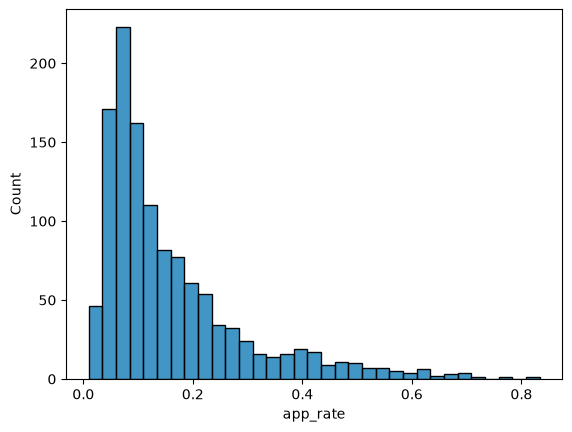

In [4]:
sns.histplot(hs_enroll, x='app_rate')

This particular histogram shows the **count** for our `'app_rate'` values, collected in bins.

Great, we're able to visualize our data! From here, we can begin to notice things about the **distribution** of our data. One important aspect of distributions is their *spread**, or **variation**. Looking at this particular distribution of `'app_rate'`, we can ask: Why is there so much variation in application rates across schools?

There are many possible reasons. Many different factors can influence the decision to apply:

- Money
- Distance
- Academic resources
- Individual and family priorities

And there are many other factors as well!

## Finding Additional Data

Do we have this data? Some of it we may not be able to access, or the data simply may not have been collected. It is important, though, to try to look for relevant data.

For now, we can go back to the [California Department of Education website](https://www.cde.ca.gov/ds/), where we found the 12th grade enrollment data for all California public schools with a 12th grade.

```{image} images/ca_doe.png
:alt: A screenshot of the California Department of Education's Data & Statistics page, which has the following description: "Obtain access to educational data, statistics, and information about California's students and schools. There are three visible links: a page titled "DataQuest," a page titled "Data Reports," and a page titled "Downloadable Data Files." Descriptions of these are in a dropdown below.
:width: 500
```

:::{dropdown} Descriptions of Links
1. DataQuest
    - The description is: "DataQuest is the CDE's public data reporting website that provides meaningful data and statistics about California's K–12 public education system."
2. Data Reports
    - The description is: "Reports with data and statistics about California's K–12 public education system."
3. Downloadable Data Files
    - The description is: "Downloadable files with data and statistics about California's K–12 public education system."
:::

As with last time, we want to select the option labeled "Downloadable Data Files," where we can find the raw files and process them ourselves. Once you select this option, you will see a [page listing various datasets](https://www.cde.ca.gov/ds/ad/downloadabledata.asp) from the California Department of Education.

For the grade 12 enrollment data, we used the dataset labeled "Annual Enrollment." There is also a dataset labeled "Free or Reduced-Price Meal (FRPM)." This information is often used as a proxy for socioeconomic status, as use of these free and reduced-price meals can be an indicator of student poverty. 

This can certainly be useful, but for now, we will use the dataset labeled "Public School and District" to explore a different factor we listed earlier: the distance of all public schools to UC Berkeley.

However, we end up with a small issue. The dataset doesn't have this exact information! The dataset does have the latitude and longitude for each school, so we once again have to be scrappy and calculate the distance using UC Berkeley's own latitude and longitude and the usual formula for calculating distance between pairs of $(x,y)$ coordinates.

In [5]:
full = pl.read_csv('data/pivoted-ucb-data-w-everything.csv')

In [6]:
full = full.with_columns(app_rate = pl.col('applied') / pl.col('grade_12'))

full = full.filter(pl.col('app_rate').is_not_null())
full = full.filter(pl.col('app_rate') <= 1)

In [13]:
full

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639,0.153425
…,…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834,0.057554


For now, we will provide you with a copy of our earlier dataset with this distance data already joined to it (the `'dist_to_ucb_miles'` column). This table also contains the percent of students at each school who use free and reduced-price meals (the `'pct_free_reduced'` column), as well as whether or not each school is a charter school (he `;is_charter'` column).

### Difficult Joins

One of the reasons for us dealing with this join for you behind the scenes is that this is not an entirely straightforward join.

We are joining these datasets on school name, which means that rows from the different tables are joined if they share the same school name. This can be an issue, as school names can be entered differently in different datasets! One may be entirely capitalized while another is not, or one may abbreviate certain terms that another does not. For example, we would have to know that "AB Miller" is equivalent to "Alfred Barnes Miller."

This is called a **fuzzy match**. It's a tricky problem, and you may want to search for others' past solutions to similar problems. You can also ask an LLM, but this may not provide you with a working solution, so you would need to iterate.

## Box plots vs Histograms

Earlier, we briefly discussed box plots and histograms as ways of visualizing the distribution of a **single, quantitative variable**. Here is the box plot for the distribution of school distances to UC Berkeley's campus.

<Axes: xlabel='dist_to_ucb_miles'>

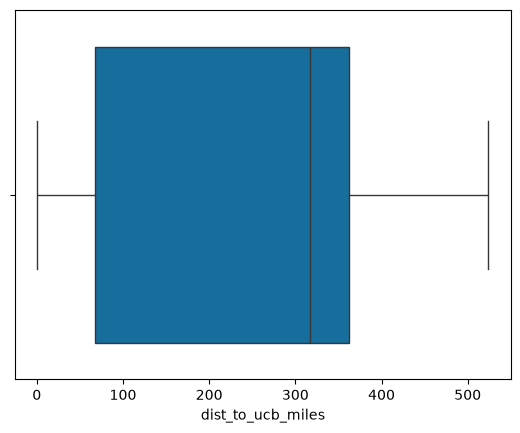

In [7]:
sns.boxplot(full, x='dist_to_ucb_miles')

**English:**
  
Make a box plot of the values in `'dist_to_ucb'`.

**Seaborn code:**
  
`sns.boxplot(full, x='dist_to_ucb_miles')`

Again, you can observe a number of facts about the data. The line in the center of the box is the median, or second quartile (Q2). The left and right edges of the box are the first and third quartiles (Q1 and Q3), respectively.

The whiskers usually mark the most extreme data points that aren't determined to be outliers. This box plot has no dots beyond the whiskers, so there are no outliers in this dataset. The ends of the left and right whiskers then represent the minimum and maximum of the data, respectively.

### Modality

Looking at the above box plot, you might assume a few things about the shape of the corresponding histogram. For example, you might assume that there is a peak at the median. The median is also much closer to Q3 than to Q1, so you might assume that the histogram has a left skew. Let us take a look:

<Axes: xlabel='dist_to_ucb_miles', ylabel='Count'>

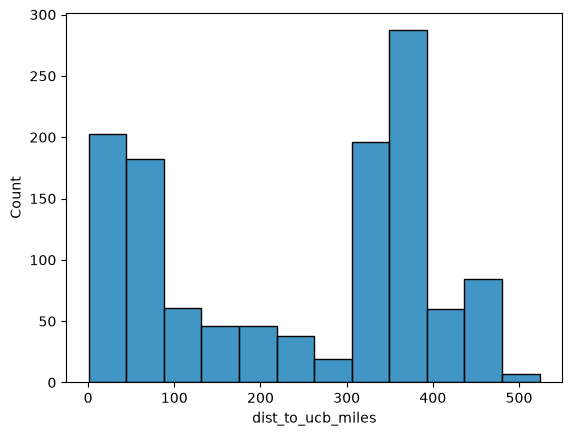

In [8]:
sns.histplot(full, x='dist_to_ucb_miles')

**English:**
  
Make a histogram of the values in `'dist_to_ucb_miles'`.

**Seaborn code:**

sns.histplot(full, x='dist_to_ucb_miles')

We noted at the end of the last chapter that distributions may have more than one **mode**, which you can see reflected in this histogram that appears to have two, or even three, separate peaks (modes). We also noted that this information is entirely hidden by box plots.

We can increase the number of bins to get more detail as well.

<Axes: xlabel='dist_to_ucb_miles', ylabel='Count'>

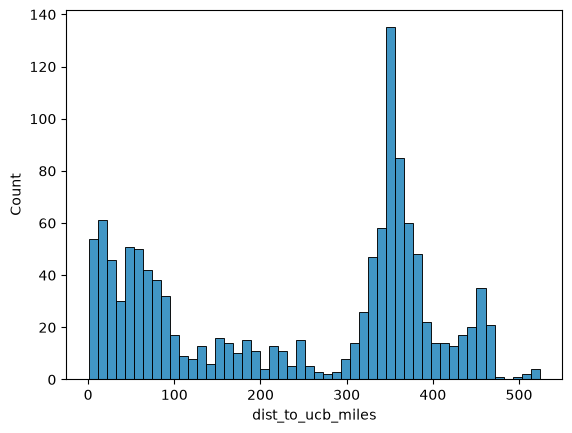

In [9]:
sns.histplot(full, x='dist_to_ucb_miles', bins=50)

**English:**
  
Make a histogram of the values in `'dist_to_ucb_miles'`, using 50 bins.

**Seaborn code:**
  
`sns.histplot(full, x='dist_to_ucb_miles', bins=50)`

It becomes fairly clear when looking at this more detailed histogram that there are three distinct peaks (maybe even four, if you count the spike close to 0 as distinct from the peak around 40 miles).

:::{note} Too many bins?
More bins is not always better! Having too much detail in a histogram can lead to noise that distracts from actually important patterns. Perhaps those anomalous spikes are of interest, but they can take away from the bigger picture.
:::

Why would this be? Here, it is helpful to check out a map of California, marked with population density.

```{image} images/cali_map.png
:alt: Map of California marked to show population centers. UC Berkeley's campus is marked on the map. There are dense areas very close to Berkeley, including a little to the south in the south Bay Area, and a little to the northeast in Sacramento. There is a very large dense area far to the south, around Los Angeles. There is another dense area a little south of Los Angeles, in San Diego.
:width: 400
```

1. There are a few areas of high population right near UC Berkeley, including San Francisco, San Jose, and Sacramento. This accounts for the peak closest to 0.
2. There is an area of very large population much farther away, in Los Angeles, which accounts for the tallest peak around 350 miles away from UC Berkeley.
3. There is a somewhat smaller area of high population just south of Los Angeles, which represents San Diego, and accounts for the peak around 450 miles.

#### Value Counts and Grouping

We can also use a helpful `polars` method to create a DataFrame of the **count** of rows (each representing a school) **for each** unique value of `'city'`. 

In [45]:
full = pl.read_csv('data/pivoted-ucb-data-w-everything.csv')

In [46]:
(full['city']
 .value_counts()
 .sort('count', descending=True)
 .head(10)
)

city,count
str,u32
"""Los Angeles""",112
"""San Diego""",41
"""San Jose""",31
"""Oakland""",28
"""Sacramento""",28
"""Stockton""",19
"""San Francisco""",18
"""Fresno""",17
"""Bakersfield""",16


In [48]:
full = full.with_columns(app_rate = pl.col('applied') / pl.col('grade_12'))

full = full.filter(pl.col('app_rate').is_not_null())
full = full.filter(pl.col('app_rate') <= 1)

**English:**
  
For each city, count the number of rows.

**Polars code:**
  
```python
(full['city']
 .value_counts()
 .sort('count', descending=True)
 .head(10)
)
```

**SQL code:**
  
```sql
SELECT city, COUNT(*) AS count
FROM full
GROUP BY city
ORDER BY count DESC
```

Here, we pulled out the `'city'` column by applying brackets directly to our DataFrame. We then used `.value_counts()` to create a DataFrame with one row **for each** unique value of `'city'` and their corresponding number of rows in the original `full` dataset.

We then sorted by this row count column in descending order, so that the cities with the most schools are at the top. These happen to correspond well to the modes we observed in the `'dist_to_ucb'` histogram. Los Angeles and San Diego each represent their own mode. San Jose, Oakland, Sacramento, Stockton, and San Francisco together account for the other mode.

Finally, we used `.head(10)` to limit our data to the first 10 rows. `.head` takes an argument for the number of rows, but defaults to the first 5 rows if you do not pass an argument.

:::{note} Organizing Your Code
You may notice that we wrapped our code in parentheses. This allows us to chain our methods in a more organized fashion, and put each method on a separate line. The parentheses prevent Python from responding with a syntax error when we do this.
:::

This kind of operation, where we do something **for each** unique value of a column, is an example of **grouping**. This is an extremely common kind of operation, and we will get much practice with this later.

## 2-D Relationships and Visualizations

Returning to our exploration of the distribution of application rates, we were trying to explain why there is so much variation in application rates across schools. We considered a few factors, including distance (discussed in the previous section) and socioeconomic status. 

Remember that we do not have direct access to information about socioeconomic status. However, we can use the percent of Free and Reduced-Price Meals (FRPM) as a proxy. This brings us to our next topic: Exploring the relationships between different variables. 

For now, we shall try to examine how do application rates **correlate** with FRPM percentage. First, a reminder of our augmented admissions dataset:

In [49]:
full.head()

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639,0.153425


### Scatter Plots and Trend Curves

Let's check out the relationship between `'app_rate'` and `'pct_free_reduced'` using a **scatter plot**.

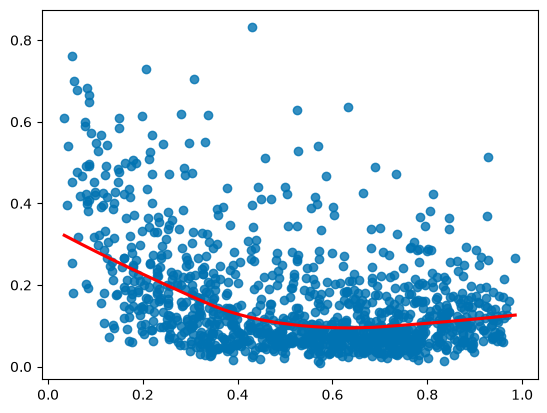

In [50]:
sns.regplot(full,
            x='pct_free_reduced',
            y='app_rate',
            lowess=True, 
            line_kws={"color": "red"}
            );

**English:**
  
Make a scatter plot with `'pct_free_reduced'` on the x-axis and `'app_rate'` on the y-axis, and add a red LOWESS line.

**Seaborn code:**

```python
sns.regplot(full,
            x='pct_free_reduced',
            y='app_rate',
            lowess=True, 
            line_kws={"color": "red"}
            )
```

Box plots and scatter plots are great for a single quantitative variable, but we need a scatter plot for a relationship between two quantitative variables. A scatter plot allows us to see each point's placement along two separate features.

Usually, we will want to look for some kind of general pattern in the relationship between these two features in the data. In other courses, you may have seen a scatter plot with a line draw through it to indicate a linear relationship. We would call this a regression line.

Instead of using `sns.scatterplot`, we will use `sns.regplot` because it allows us to draw such a trend  through our data. However, our data does not appear to follow a linear pattern. The parameter `lowess=True` changes our trend line into a non-linear trend curve using LOWESS (Locally Weighted Scatterplot Smoothing).

:::{note} What is LOWESS?
Very roughly, LOWESS finds the average of all points within each "bin" of the data and connects the dots, but this is an oversimplification.
:::

:::{note} Semicolons Clean Up Output
If you compare the actual code we used to generate the above scatter plot with the code listed in the "Seaborn code" box above, you may notice an additional semicolon at the end of our actual code. This simply hides some information about the plot from printing right above the plot. Play around with this to observe the difference.
:::

### Weighting Points

Perhaps our points should not all equally influence the overall shape of this relationship. Along with our original scatter plot from earlier, let's check out a few versions where we weight the size of the points using different features.

In [68]:
sns.scatterplot(full,
                x='pct_free_reduced',
                y='app_rate',  
                size='grade_12',
                sizes=(1,100)
                );

ValueError: Could not interpret value `app_rate` for `y`. An entry with this name does not appear in `data`.

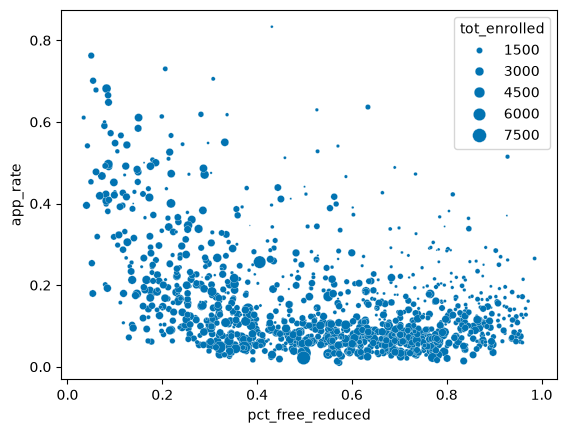

In [52]:
sns.scatterplot(full,
                x='pct_free_reduced',
                y='app_rate',  
                size='tot_enrolled',
                sizes=(1,100)
                );

In the plots above, you will see a legend indicating the feature used to weight the size of the points. These two plots weight the points (schools) by the number of Grade 12 students and the total number of enrolled students at each school, respectively. The third plot weights points by the number of students who applied from each school.

You may observe that the shape of the general pattern becomes more clear in these two plots. The sparse points representing schools that have both larger percentages of FRPM and higher application rates now appear more as exceptions to an otherwise more cohesive pattern. In these examples, larger points intuitively represent larger schools, and the pattern better reflects most students.

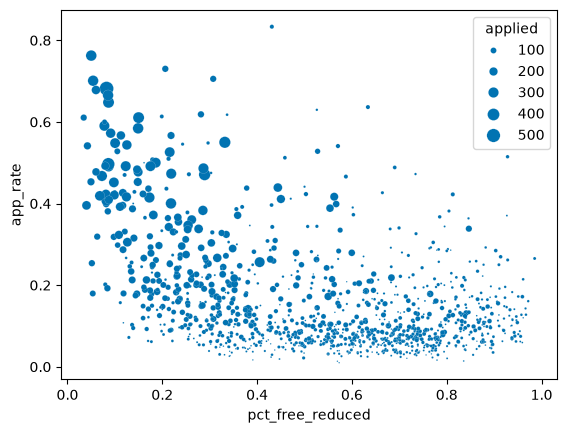

In [53]:
sns.scatterplot(full,
                x='pct_free_reduced',
                y='app_rate',  
                size='applied',
                sizes=(1,100)
                );

This third plot, however, looks less similar to the first two. Rather than have point sizes represent larger student populations, this plot has point sizes represent the number of students in each school who applied to UC Berkeley. This ends up being somewhat redundant with the `'app_rate'` y-axis, because higher application rates are tied to higher numbers of students applying.

Which of these is best? **There is no single answer to this question.** It depends on your purpose.

If you wish to emphasize the pattern that represents most students, you might go with points weighted by `'grade_12'` or `'tot_enrolled'`. If you wish to further emphasize schools with high application rates, you might go with points weighted by `'applied'`. Also, we said that this is somewhat redundant with `'app_rate'`, but they are still distinct; a small enough school could have a very high application rate, but a small overall number of students applying.

Here is the scatter plot weighted by Grade 12 enrollment again, though you may notice a difference:

<Axes: xlabel='pct_free_reduced', ylabel='app_rate'>

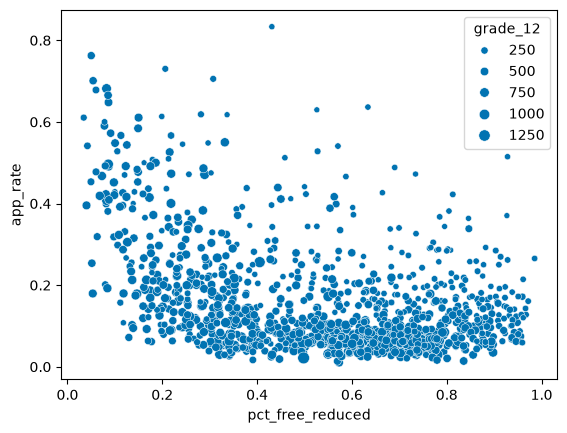

In [54]:
sns.scatterplot(full,
                x='pct_free_reduced',
                y='app_rate',  
                size='grade_12'
                )

**English:**
  
Make a scatter plot with pct_free_reduced on the x-axis and app_rate on the y-axis, with points sized by 12th grade enrollment.

**Seaborn code:**
  
```python
sns.scatterplot(full,
                x='pct_free_reduced',
                y='app_rate',  
                size='grade_12'
                )
```

:::{note} Additional Parameters
If you expand the code for our original three weighted-size plots, you will notice an extra parameter that says `sizes=(1, 100)`. This changes the range of possible sizes, and allowed us to make our smaller points much smaller. This is the kind of specific detail that is helpful to just search up when needed, rather than have memorized.
:::

Assume that we have decided to use `'grade_12'` for our point size. Also remember that our task is to find 5 schools that defy typical patterns of application, admission, and/or attendance. If we examine our size-weighted plot, points that are both large and far from the general pattern draw our attention.

If we were instead examining our original scatter plot, our attention may instead simply be drawn to the points farthest from the general pattern, with no regard for how many students these points represent.

## Approximation and Caveats

We will now get some more practice with extracting  information from our data and translating problem-solving into code. Let's try to add a column for the number of Grade 12 students in each school who use Free and Reduced Price Meals.

How do you first approach this? One initial thought may be to multiply the total number of Grade 12 students in each school (`'grade_12'`) by the percent of each school that uses Free and Reduced Price Meals (`'pct_free_reduced'`). Let's check out how we would do that.

In [55]:
full_new = full.with_columns(
    (pl.col('pct_free_reduced') * pl.col('grade_12')).cast(int).alias('num_frl_12th')
)

full_new.head()


school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate,num_frl_12th
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546,332
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589,49
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347,201
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894,0.411043,220
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639,0.153425,171


**English:**
  
Create a new column approximating the number of Grade 12 students using Free and Reduced Price Meals at each school.

**Polars code:**
  
```python
full_new = full.with_columns(
    (pl.col('pct_free_reduced') * pl.col('grade_12')).cast(int).alias('num_frpm_12th')
)
```

**SQL code:**
  
```sql
SELECT pct_free_reduced * CAST(grade_12 AS INT) AS num_frpm_12th
FROM full
```

We have used `.with_columns` again to add a new column. As with our creation of `'app_rate'`, we pull out existing columns using `pl.col` and use them to perform an element-wise operation using both columns.

This time, though, we add two new twists. The first is that we use `.cast` to convert the result of this multiplication into values of the integer type. This is because the multiplication will likely result in many values that are not exact integers, but we hopefully have integer counts of Grade 12 students using FRPM. More broadly, `.cast` converts values of one type to another type.

The second new twist is using `.alias` to name our new column. When we created our application rate column, we used `.with_columns(app_rate=...)` to name our new column directly, whereas `.alias` allows us to name our new column after the operation that defines it.

:::{note} Casting Conventions
In `polars`, casting a `Float64` type to `Int64` type truncates the floating number. That is, `23.2` and `23.7` are both cast into `23`. However, `SQL` behavior varies depending on the version of SQL you are using, and may either truncate or round to the nearest integer. Check the rule for your version of SQL!
:::

There is an issue with the way that we calculated the number of Grade 12 students using FRPM at each school. The `'pct_free_reduced'` is a school-wide percent, which we are assuming is also accurate for Grade 12 students specifically. However, there are some factors that could cause this assumption to not hold:

- More students drop out towards later grades.
    - It is possible that the students who drop out are particularly likely to use FRPM.
    - This would cause the school-wide percent to be an **over-estimate** of Grade 12 students using FRPM.
- Schools in less wealthy districts are more likely to close.
    - This could lead to an influx of less wealthy students in younger grades, who are more likely to use FRPM.
    - This would cause the school-wide precent to be an **under-estimate** of Grade 12 students using FRPM.
- Other events may have changed the demographics of the community that feeds into a given school.
    - This could lead to younger students having a different precent of FRPM use than older students as a result of the braoder demographic change.

It is important to keep such nuances in mind when creating approximations in this way. You should **communicate your assumptions**, and note any potential caveats.

## Summarizing Patterns

We were tasked to find 5 California public high schools that **defy typical patterns** of application, admission, and/or attendance. However, we really haven't defined "typical patterns". (We also haven't touched admission or attendance at all.) We should spend some time understanding broad patterns in all three outcomes.

Let's re-examine our choice of 2-D visualization for the relationship between application rate and percent of FRPM use.

<Axes: xlabel='pct_free_reduced', ylabel='app_rate'>

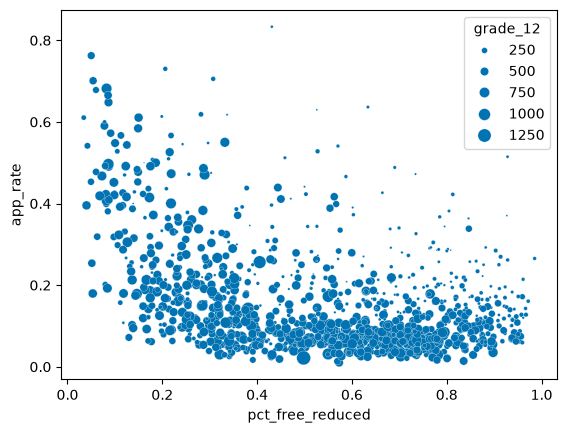

In [56]:
sns.scatterplot(full,
                x='pct_free_reduced',
                y='app_rate',  
                size='grade_12',
                sizes=(1,100)
                )

Earlier, we used a LOWESS curve to emphasize the pattern in our data. There are ways to summarize the pattern using fewer data points, simplifying our visualization in the process. Here is one such example:

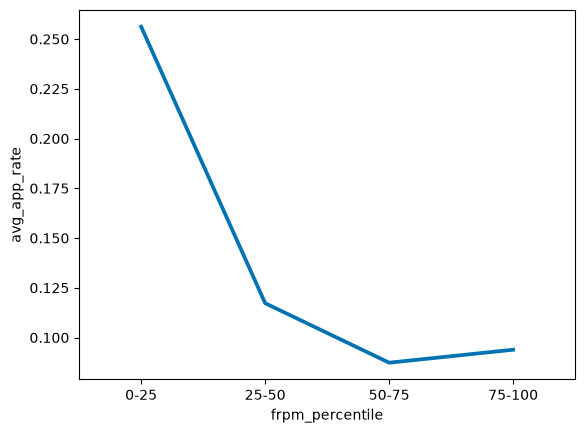

In [57]:
full_percentile_raw = full.with_columns(
    frpm_percentile_raw=pl.col('pct_free_reduced').rank()/pl.col('pct_free_reduced').count())

full_percentile = full_percentile_raw.with_columns(
    frpm_percentile=pl.col('frpm_percentile_raw').qcut(4, labels=["0-25", "25-50", "50-75", "75-100"])
)

per_percentile = full_percentile.group_by('frpm_percentile').agg(
    applied= pl.col('applied').sum(),
    grade_12 = pl.col('grade_12').sum(),
    avg_app_rate=  pl.col('applied').sum()/pl.col('grade_12').sum()
    )

sns.pointplot(per_percentile,
              x='frpm_percentile',
              y='avg_app_rate',
              order=["0-25", "25-50", "50-75", "75-100"],
              marker=''
              );


The x-axis no longer consists of the actual percents of FRPM use. Instead, it now has ticks representing percentile bins of those original percent values. Accordingly, the "0-25" bin summarizes (or **aggregates**) information about the lowest fourth of `'pct_free_reduced'` values.

**This is not the same as capturing FRPM percents with values between 0 and 0.25!** If all of the original values were less than 0.25, this bin would still capture the lowest fourth of the values, rather than all of the values.

We mentioned that each point now summarizes/aggregates information about its respective bin. In this case, the summary/aggregation is the average application rate for each bin, measured along the y-axis. This presents a much simpler picture, with a cleaner plot and a high-level summary of the pattern.

Whether or not this is preferable depends on the particular use case, but also the audience. An audience with little to no domain expertise, or the general public, may be able to see the pattern better with this simplified plot. An audience of other researchers in the field may prefer the more detailed view, but again, **this is case-dependent.**

### Tidy Data

How would we generate the simplified graph above? We will fully explore this question next chapter, and have intentionally hidden the code for now. A good starting point, though, is to consider what information we would need in order to construct this plot.

In our original scatter plot, each point represents one school. This corresponds nicely to our `full` table, where each row represents one school. Thus, one point in our visualization corresponds to exactly one row in the table that generated it. This is an example of **tidy data**, and is a well-organized approach to data manipulation and visualization.

Let's think about the information you need in order to create our new, simpler visualization.

- What shape should the shape be of the table that creates this?
    - How many rows?
    - How many columns?
- What should each row and column represent?
- How do we manipulate the data we have in order to get our table into the correct form?

As per tidy data principles, we want 1 row for each point, so our table should have 4 points. We also have 2 features, one measured along the x-axis and the other along the y-axis, so our table needs two columns.

In [58]:
per_percentile = per_percentile.select(
    pl.col('frpm_percentile'),
    pl.col('avg_app_rate')
)

per_percentile = per_percentile.filter(pl.col('frpm_percentile').is_not_null())

per_percentile = per_percentile.sort(by='frpm_percentile', descending=False)

per_percentile

frpm_percentile,avg_app_rate
cat,f64
"""0-25""",0.256207
"""25-50""",0.117248
"""50-75""",0.087358
"""75-100""",0.093879


If we had a second line in our plot, measuring the same information for a different category, how would the shape of the necessary table change? Well, we would have an additional 4 points, so we would need 8 rows. We would also need some way to distinguish the four points from the first line with the four points from the second line, so we would need a third column representing this distinguishing category.

## Introduction to Grouping

How would we create this four-row table? We need to explore a (somewhat) new operation. We have explored the following operations already:

- **View** a preview of a dataframe
- **Select** specific columns
- **Create** new columns
- **Filter** to specific rows
- **Order** the data by the values in a column
- **Calculate** summary statistics for one or more columns
- **Visualize 1-D** (one-dimensional) data with a box plot or histogram
- **Visualize 2-D** (two-dimensional) data with a scatter plot or line plot

We will describe our new operation as follows:
- **Group** by some variable, and then do something (most often, **aggregate**)

In plain English:
- "**For each unique value** of COLUMN(S), do SOMETHING."

We already touched on this when we used `.value_counts` earlier to count the number of rows corresponding to each city. It is a bit of a shortcut method for a specific subcategory of grouping, but we can think about it through the same paradigm we will use for all grouping operations:
1. **Split**
2. **Apply**
3. **Combine**

```{image} images/grouping_value_counts.png
:alt: Diagram of the Split-Apply-Combine paradigm for grouping operations. Thorough description follows in main text.
:width: 500
```

We have a toy version of our original `'city'` column, with three unique values of `'city'` that are each represented in multiple rows.

1. First, we **split** this data along each unique value of the column, creating three temporary sub-dataframes. Each of these temporary sub-dataframes contains only rows corresponding to a single unique value of `'city'`.

2. We then **apply** some operation across the values in each of these sub-dataframes. Usually, this is some sort of **aggregation** operation that produces a single value **for each** unique value of our grouping column. In this case, we are finding the **count** of rows **for each** unique value of `'city'`. This reduces our three sub-dataframes into just three rows, one row per split section.

3. Finally, we **combine** these three aggregated sections together, creating a new dataframe with just three rows in total (one row per unique value of `'city'`). Each row now represents a unique city, rather than a unique school!

In [64]:
full = pl.read_csv('data/pivoted-ucb-data-w-everything.csv')

In [65]:
(full['city']
 .value_counts()
 .sort('count', descending=True)
 .head(10)
)

city,count
str,u32
"""Los Angeles""",112
"""San Diego""",41
"""San Jose""",31
"""Oakland""",28
"""Sacramento""",28
"""Stockton""",19
"""San Francisco""",18
"""Fresno""",17
"""Bakersfield""",16


Recalling our earlier discussion of `.value_counts`, the plain English language for this operation would be:
"**For each** unique value of city, *count** the number of rows."

Let's wrap up by using this paradigm for an aggregation other than value counts.

```{image} images/grouping_mean_enroll.png
:alt: Diagram of the Split-Apply-Combine paradigm again, but using average school enrollment for each city instead of number of schools for each city. Thorough description follows in main text.
:width: 500
```

This is largely the same process as before, but with a different operation in the **apply** step. We still begin by **splitting** the original dataset into separate groups **for each** unique value of `'city'`.

However, our summary value for each group now involves aggregating over another feature! Rather than simply return the number of rows in each group, we will return the average of all `'tot_enrolled'` values for each group. We then combine these aggregated groups into a new table, with the **average enrollment for each city**.

In [67]:
full.group_by('city').agg(mean_enroll=pl.col('tot_enrolled').mean()).sort(by='city', descending=False).head(10)

city,mean_enroll
str,f64
"""Acton""",1963.0
"""Adelanto""",2229.0
"""Agoura Hills""",1728.0
"""Alameda""",909.25
"""Albany""",1117.0
"""Alhambra""",2139.0
"""Aliso Viejo""",2608.0
"""Alta Loma""",2400.0
"""Altadena""",207.0


The plain English language for this operation is:
"**For each** unique value of city, **compute the mean** number of students enrolled across its schools."

We have hidden the `polars` code for now, but will examine it in the following chapter.

## Takeaway

We have further examined distributions of data, relationships between different features, and some considerations when visualizing these distributions and relationships. We have also considered the importance of defining your audience and your goal when selecting representations of your data and communicating key results. Finally, we began our discussion of common grouping operations, and related these to the idea of summarizing our data. 

We have already spent considerable time on this one task: identifying 5 schools that defy typical patterns of application, admission, and/or attendance. **This is not unusual.** Real data science work can often involve a lengthy EDA (Exploratory Data Analysis) process for a single task. We will continue this process in the coming chapter! 